# Theoretical background of the study

## 1. Object detection algorithms

Before we start, we need to spend time talking about **Convolutional neural networks (CNNs)**. They are designed to **process** and **classify** images. These images are just **grids of pixels** that hold information about it's color and intensity. Each pixel is represented like a vector with **3 values**, from **0 to 255**, corresponding to the **red, green and blue (RGB) channels**. If the imgae is **grayscale**, each pixel has only **one value** for the **light intensity** at that point. [2], [8]

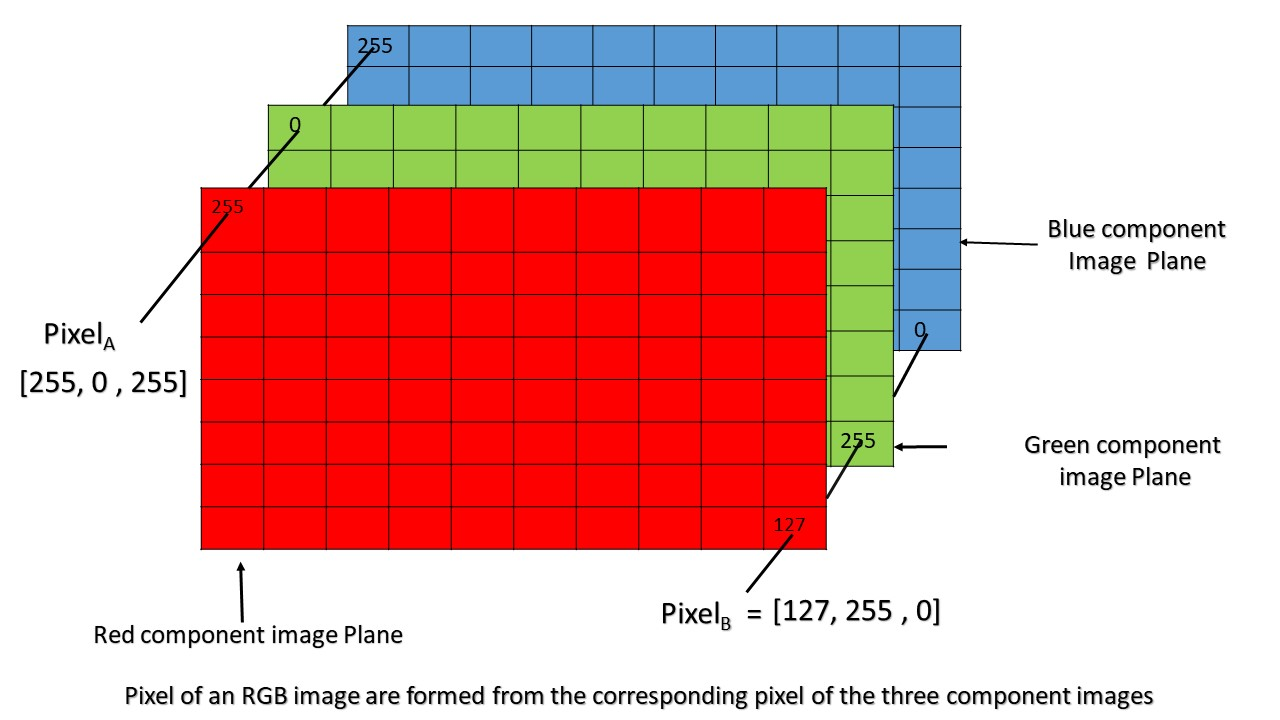

There are **4 basic concepts for neural networks (NN)**. The first one is **neuron**. This is the most basic unit in a NN and they are composed of a sum of linear funtions and non-linear function (activation function) applied to them . Then is the **input layer**. In this layer each neuron corresponds to one of the input features. Imagine that the input (image) is a 32 x 32 pixels so the input layer would have 1024 neurons. The next one is the **hidden layer**. Here each neuron is summed by the result of neurons in the previous layers and multipled by a non-linear function. The position of this layer is between the input and output. The final concept is about **output layer**. It represends the number of neurons of output classes. [4]. [9]

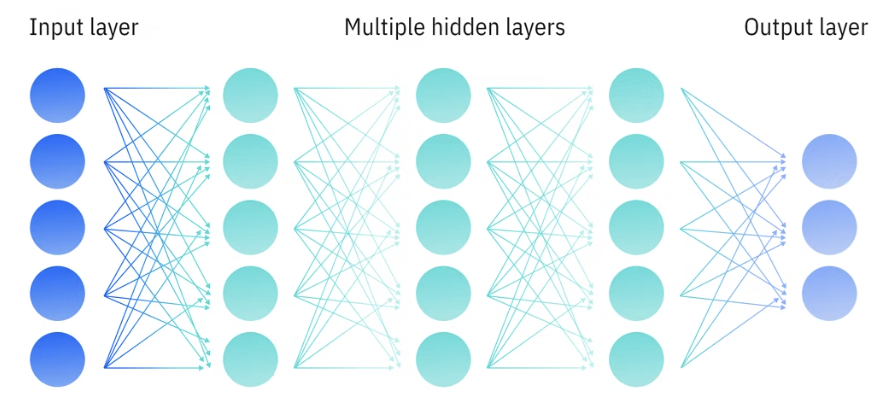

**CNNs** process this grid-like data by capturing spacial relationships between pixels. They automatically learn features through convolution operations, detects objects and reduce computational complexity by precessing local regions. [2], [22]

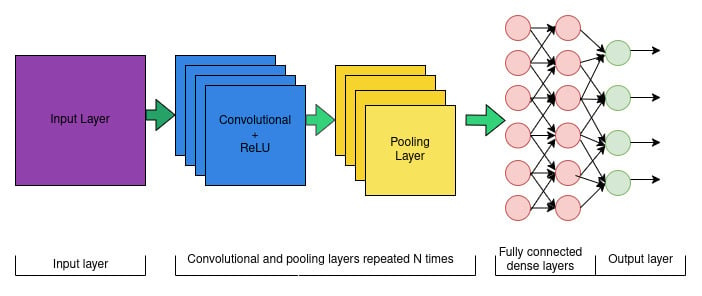

The architecture is a sequence of layers and each layer transforms one volume to another through a diffrent - **convets**. They have **7 parts**. Starting from the **input layer** that holds a 3D volume (width x height x dept ). Then **convolutional layer** that extracts features from the input data. The workflow of this layer starts from a filter (kernel) slides over the image and multiplies its values with small patches of the image. The results are summed to create a feature map that highlights patterns like edges and textures. This process is repeated across the image with stride and optional padding, efficiently extracting features while preserving spatial structure. Then the next layer is **activation**. To enable the model learn complex patterns beyond linear relationships we need element-wise activation functions (ReLU, Tanh, Leaky ReLU, etc.) to apply non-linearity. After that is the **pooling layer** that reduce the spatial dimentions of the feature maps. The next one is **flattening**. It converts the multi-dimensional features maps into a one-dimensional vector then this vector is passed through **dense layer** that produce the final classification score. The hole process ends with a **output layer** that covers final scores into probabilities using activation functions (**Sigmoid** - binary classification or **Softmax** - multi-calss classification). [3], [4], [5], [13]

### 1.1 You Only Look Once (YOLO)

Among other algorithms for object detection **YOLO family** is the most influential and widly used because of its high accuracy, speed and lower resource requirements . These  algorithm are primarily designed to **identify** and **categorize objects**. Since its first release in **2015**, YOLO algorithms are from **v1 to v12 (2025)**. Each version has been built on top of the previous one with enhanced features such as improved accuracy, faster processing and better handling of small objects. The name **"You Only Look Once"** refers to the fact that the algorithm requires only one forward propagation pass through the NN to make predictions - **singal stage**. [10], [11]

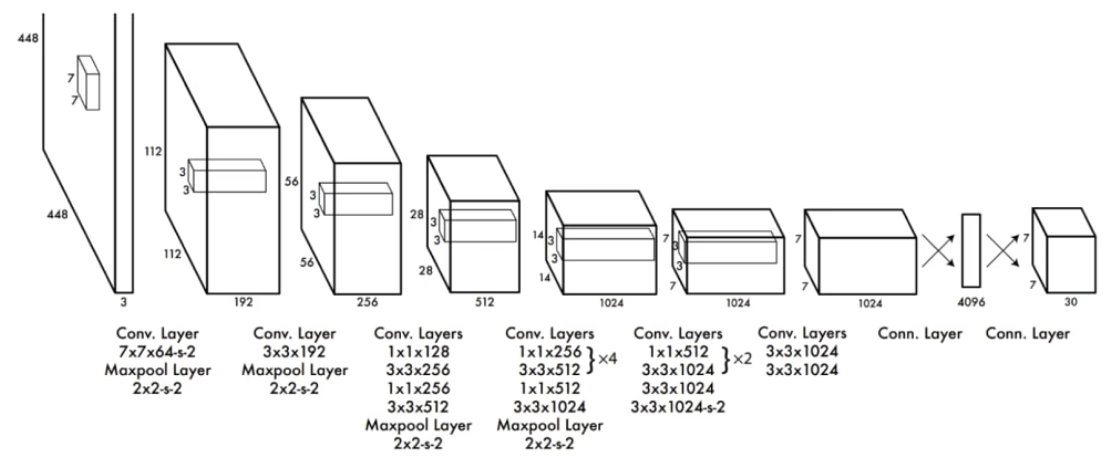

YOLO works by passing an input image through a CNN consisting of multiple convolutional and fully connected layers, initialized with pre-trained features pre-trained. The image is divided into an $S \times S$ grid, where each cell is responsible for detecting objects whose center falls within it [10], [11]. For each grid cell, the model predicts **class probabilities** $P(\text{Class}_i \mid \text{Object})$, multiple **bounding boxes** defined as $(x, y, w, h)$, and **confidence scores** given by 

$$\text{Confidence} = P(\text{Object}) \cdot IoU$$

where 

$$\mathrm{IoU} = \frac{A \cap B}{A \cup B}$$

measures the overlap between predicted and ground truth boxes. The complete output for each grid cell can be represented as 

$$(p_1, \dots, p_C, c_1, x_1, y_1, w_1, h_1, \dots, c_B, x_B, y_B, w_B, h_B)$$

During training, only the bounding box with the highest IoU is responsible for prediction, allowing different predictors to specialize in detecting objects of various shapes and sizes [23]. The final **class-specific score** is computed as 

$$\text{Score}_i = P(\text{Class}_i \mid \text{Object}) \cdot \text{Confidence}$$

After all predictions are generated, **non-maximum suppression (NMS)** is applied to remove overlapping bounding boxes and retain the most confident detections [24], [27]. The training process optimizes a combined **loss function** defined as 

$$\text{Loss} = \lambda_{coord} \cdot \text{Loss}_{bbox} + \text{Loss}_{confidence} + \text{Loss}_{class}$$

balancing localization, confidence, and classification errors.

In this study, it is used **Ultralytics YOLOv8**. It is designed to deliver high detection accuracy while maintaining fast inference speed. The YOLOv8 architecture is typically composed of **three key parts: backbone, neck and head**. [23], [24]

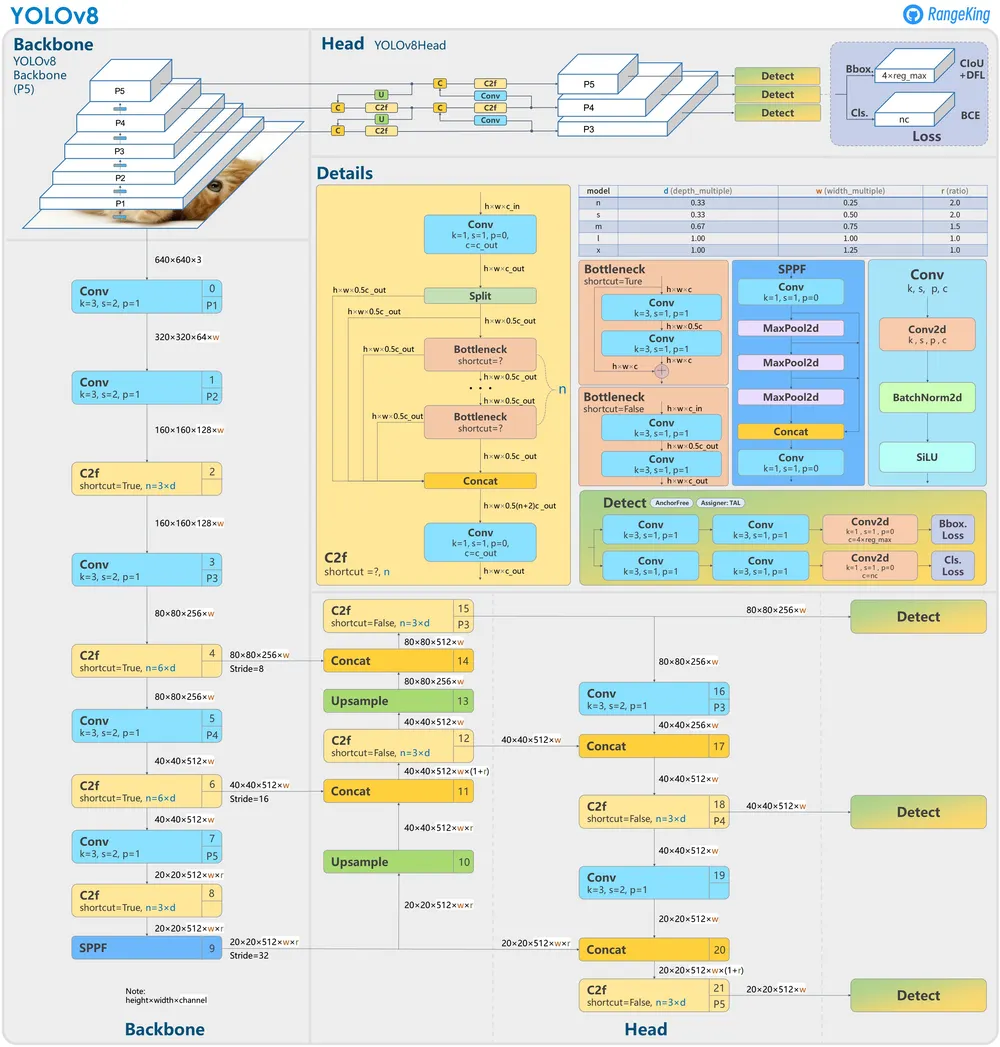

The **backbone** is responsible for **extracting hierarchical features** from the input image. It gradually reduces the spatial resolution while increasing the depth of feature maps across different stages **(P1 to P5)**. A key component in this part of the network is the **C2f module**, which replaces earlier CSP-based blocks and improves information flow and feature reuse. In the deeper layers, the backbone also includes the **Spatial Pyramid Pooling – Fast (SPPF)** module which enlarges the receptive field through multiple pooling operations, allowing the model to capture both local details and global context efficiently. [11]

The **neck** connects the backbone and the head, and its main function is to fuse features coming from different scales. It follows a structure inspired by **Feature Pyramid Networks (FPN)** and **Path Aggregation Networks (PAN)**. In this stage, features are upsampled to higher resolutions and concatenated with corresponding backbone features. These fused features are further refined using **C2f blocks**, which improves the model’s ability to combine semantic information from deep layers with spatial details from shallow layers. This multi-scale fusion is essential for detecting objects of varying sizes. [11], [23]

The **head** is responsible for producing the final detection results. YOLOv8 uses a **decoupled head design**, meaning that classification and bounding box regression are handled separately. The model generates predictions at **three different feature scales: P3 for small objects, P4 for medium objects, and P5 for large objects**. Each scale outputs bounding box coordinates and class probabilities. [24]

**For training**, the head uses multiple loss functions. **Complete Intersection over Union (CIoU)** is applied to improve bounding box regression accuracy, while **Distribution Focal Loss (DFL)** enhances precise localization. In addition, **Binary Cross-Entropy (BCE)** is used for classification tasks. This combination of loss functions helps improve overall detection performance. [24]

Overall, YOLOv8 processes the image through **feature extraction** in the backbone, **feature fusion** in the neck, and **multi-scale prediction** in the head. This design enables the model to achieve both **high accuracy** and **real-time inference speed**. [27]

### 1.2. Region-based Convolutional Neural Network (R-CNN)

Traditional CNNs with fully connected layers struggle with object detection tasks when there are multiple objects with diffrent sizes and positions within an image. Here comes the role of **R-CNN** that represents a better way of handling these difficulties. It uses **selective search** algorithm to ganerate **around 2000** region proporsal from an image. They are individually processed to detect and localise objects. Selective search works by dividing image into small patches, group them together based on similarities (color, texture, etc.), combine those groups into larger rectangles that might contain objects and finally make those ~2000 region proposals. This process is like a simplified version of **image segmentation**. [8], [17]

**R-CNN** has **4 main stages**. The first one is **regional propolsal**. After that is **feature extraction**. Here each proposal is warped to a fixed size and passed through a pre-trained CNN to extract features and outputs fixed-length feature vector. Then is the time for **classification**. Each feature is fed into a classifier to determine the class of the object within each regioon proposal. R-CNN typically uses **Support Vector Machines (SVMs)** for classification. For each class, a unique SVM is trained to determine whether or not the region proposal contains an instance of that class. In addition to classifying objects, R-CNN also performs **bounding box regression**. For each class, a separate regression model is trained to refine the location and size of the bounding box around the detected object. After classifying and regressing bounding boxes for each region proposal, R-CNN applies **NMS**. [5], [17]

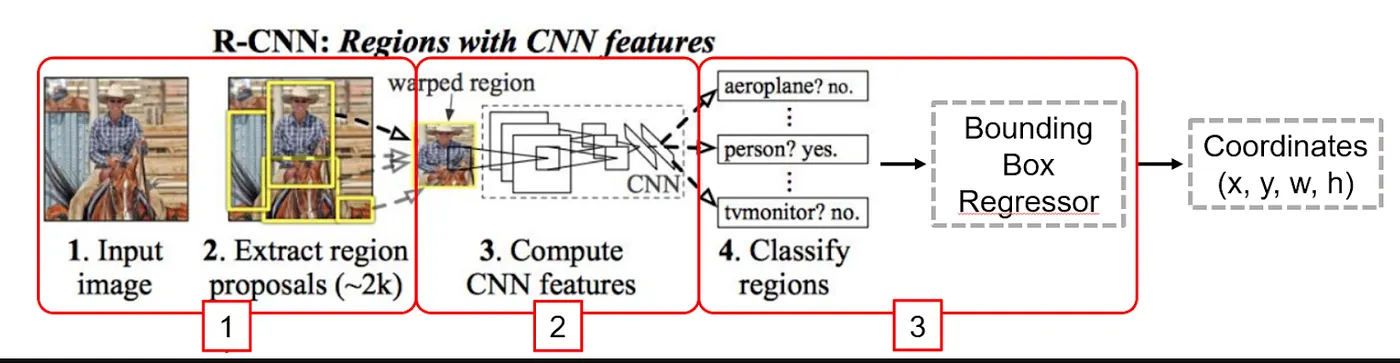

Again like YOLO, there are diffrent variations. **Fast R-CNN** processes the entire image only once to create a shared feature map (single stage), making it much faster than earlier methods. It replaces **SVM** with a **softmax classifier** for end-to-end training and improves bounding box accuracy. It converts raw **network scores (logits)** into a probability distribution that sums to 1.0, representing the probability of each class. [6], [21]

$$ \text{Softmax}(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} $$

where:
- $z_i$ is $i$-th logit of the model;
- $K$ is the number of classes.

**Faster R-CNN** builds on this by adding a **Region Proposal Network (RPN)** that generates object proposals directly from feature maps, eliminating selective search. This makes it significantly faster while maintaining high detection accuracy. [15]

**Mask R-CNN** extends Faster R-CNN by adding pixel-level segmentation masks for each object. It uses **Region of Interest Align (RoIAlign)** for more precise feature extraction and improves detection across different object sizes. RoIAlign works by avoiding rounding errors and preserving spatial accuracy. It first maps each RoI onto the feature map using continuous (floating-point) coordinates and divides it into evenly sized bins. Inside each bin, several sampling points are selected at fixed positions. The feature values at these points are then computed using **bilinear interpolation** based on the nearest pixels in the feature map. Finally, the sampled values within each bin are combined—typically using **max or average pooling** to produce a fixed-size, precisely aligned output. [19]

**Cascade R-CNN** uses a multi-stage detection process where predictions are refined step by step, resulting in better localization and higher precision, especially for challenging cases. 

In this study it is used **Faster R-CNN**. By using RPN the entire model can be trained end-to-end within a single unified network. Instead of relying on external algorithms, region proposals are now generated directly from the feature maps, making the system significantly more efficient. [14], [21]

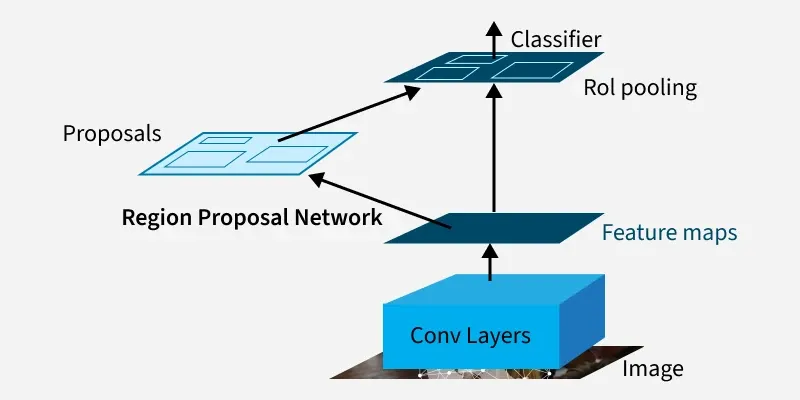

The Faster R-CNN process can be summarized in **4 main steps**. First, **features are extracted** from the input image using a CNN. Next, the **RPN** generates candidate object regions. These regions are then processed using **RoI Pooling** to ensure a fixed size without distorting the content. Finally, the processed features are passed through fully connected layers to **classify objects** and refine their **bounding boxes**. [5], [19]

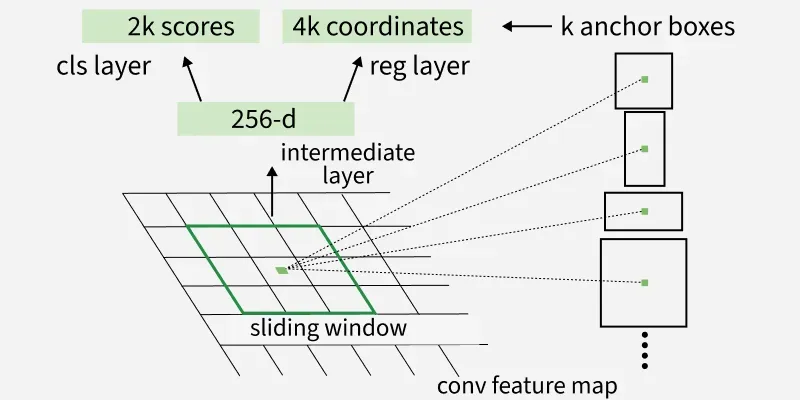

The **RPN** plays a crucial role as the **“attention mechanism”** of the network. It scans the feature maps and predicts potential object locations by outputting bounding boxes along with objectness scores. Because it operates directly on the already computed feature maps, it avoids redundant computations and significantly speeds up the detection process, bringing it closer to real-time performance. [15]

A key concept used by the RPN is **anchor boxes**. These are predefined bounding boxes of different sizes and aspect ratios that act as reference templates. The network learns to adjust these anchors to better fit objects in the image. For example, a tall narrow anchor might correspond to a distant pedestrian, while a larger one could represent a closer object. [5]

By combining the shared **CNN features**, **RPN** and the **detection network**, Faster R-CNN can simultaneously predict object locations and class probabilities. As a **two-stage detector**, it remains highly accurate and is especially effective at detecting both small and large objects, even though it is slightly slower than single-stage approaches. [21]

## 2. Metrics used to evaluate hypothesis and experimental results

### 2.1 Shannon Entropy

**Shannon Entropy** in image processing is a statistical measure of the **randomness**, **complexity** or **average** information content present in an image. It quantifies how spread out the intensity values (gray levels) are, calculated from the image histogram. **Low Entropy** means low complexity, smooth areas or sharp, simple edges (a black screen, a flat gray image). **High Entropy** means high complexity, texture, noise or high contrast (a picture of a crowded, busy forest). [20]

Shannon entropy $H(I)$ is calculated as:

$$H(I) = - \sum_{i=0}^{L-1} p(i)\,\log_2 p(i)$$

- $L$: total number of possible gray levels (256 for 8-bit images);
- $p_i$: probability of a pixel having intensity value $i$ (calculated as $p(i) = \frac{n_i}{N}$);
- Item unit: bits per pixel (when using $\log_2$).

### 2.2 Canny Edge Density

**Canny edge density (CED)** represents the concentration of detected edge pixels within a defined region of an image. It is often used to measure scene complexity, texture or for traffic analysis. It is calculated after applying the multi-stage **Canny algorithm** to create a sparse binary image. [1]

If CED is **around 0** it means that the image contains **very few edges** and if it is **hight** it means that there are **many edges**. This process **can be controlled** because if its dependency on the **hysteresis thresholding parameters** ($T_1$, $T_2$) and the **Gaussian filter size**. A **smaller threshold range** creates a denser edge image while **larger threshold** values reduce the edge count. [25]

**Canny algorithm** has **5 steps**. **The first** apply **Gaussian filter kernel** to reduce noice in the image because edge detection is sensitive to it. The equation for a kernel of size $(2k+1)×(2k+1)$ is given by:

$$H_{ij} = \frac{1}{2\pi \sigma^2}\exp\left(-\frac{(i - (k+1))^2 + (j - (k+1))^2}{2\sigma^2}\right),\quad 1 \leq i,j \leq (2k+1)$$

where:
- $H_{ij}$: value of the Gaussian kernel at position $(i, j)$;
- $i,j$: discrete row and column indices of the kernel;
- $k$: determines kernel size;
- $\sigma$: standard deviation of the Gaussian distribution (controls the amount of smoothing).

**The second step** computes **gradient intensity** and **directions** using operators like **Roberts, Prewitt or Sobel**. For example **Sobel** creates an **image emphasizing edges**. This operator is based on convolving the image with a small, separable and integer-valued filter in the horizontal ($G_x$) and vertical ($G_y$) directions. It can be determined by:

$${\mathbf {G} ={\sqrt {{\mathbf {G} _{x}}^{2}+{\mathbf {G} _{y}}^{2}}}}$$
$${\mathbf {\Theta } =\operatorname {atan2} \left(\mathbf {G} _{y},\mathbf {G} _{x}\right)}$$

where $G$ can be computed using the **hypot function** and **atan2** is the arctangent function with two arguments. The edge direction angle is rounded to **one of four angles** representing **vertical, horizontal and the two diagonals** $(0^\circ,\, 45^\circ,\, 90^\circ,\, 135^\circ)$. An edge direction falling in each color region will be set to a specific angle value, for instance, $\theta$ in $[0^\circ,\, 22.5^\circ]$ or $[157.5^\circ,\, 180^\circ]$ maps to ${0}{\degree}$. [1], [25], [26]

**The third** is applying **NMS**. It thins thick edges producing precise, one-pixel-wide edge contours because gradient magnitude alone produces thick ones. For each pixel it is determined **edge direction** by quantizing the gradient angle $\theta$ into one of four directions. Then they are **compared with neighbors**. For each pixel, identify two neighbors along the edge direction (perpendicular to gradient direction). Lastly, **suppression** is done. If the pixel’s magnitude is not greater than both neighbors, set it to zero. Otherwise, keep its original magnitude value. [25]

**The fourth step** applies **double hysteresis thresholding**. It classifies edge pixels based on their gradient magnitude using a **high and a low threshold**. Pixels above the high threshold are marked as **strong edges** while those between the thresholds are considered **weak** and those below the low threshold are removed as **noise**. This approach helps preserve **only important edges**. [1]

The final **fifth step** counts edge pixels and **calculate the ratio** over the total pixel count.

### 2.3 Average IoU

Object detection models predict both a **class label** and a **bounding box**, but predicted boxes rarely match the ground truth perfectly. To measure how well a predicted box overlaps with the true object it is used **IoU** which compares the overlap area between the predicted and ground truth boxes relative to their combined area. In some datasets, we predefine an IoU threshold (let's say 0.5) in classifying whether the prediction is a true positive or a false positive. IoU values range from 0 to 1, where 0 indicates no overlap and 1 indicates a perfect match.

$$\mathrm{IoU} = \frac{A \cap B}{A \cup B}$$

**Average IoU**, often referred to as **Mean IoU (mIoU)**, is a metric used to measure the accuracy of object detection and image segmentation models by calculating the average overlap between predicted and ground truth regions. [18]

### 2.4 mAP@[.75:.95]

To evaluate a algorithm there **Average Precision (AP)** and **Mean Average Precision (mAP)**. Before jump to them we need to know definitions for **precision** and **recall**. [16]

$$Precision = \frac{tp}{tp + fp}$$
$$Recall = \frac{tp}{tp + fn}$$

where tp, fp and fn stands for **true positive**, **false positive** and **true negative** (they are from **confusion matrix**). So **precision** is measuring the percentage of correct positive predictions among all predictions made and **recall** is measuring the percentage of correct positive predictions among all positive cases in reality. There is always **trade-off** between them. The **harmonic mean** of precision and recall is **F1 score**. This balanced matric is for classification models, particularly on imbalanced datasets. It ranges from **0 to 1**, with 1 indicating perfect ratio between them. The formula is:

$$F1 Score = 2 \times \frac{Precison \times Recall}{Precision + Recall}$$

**AP** is the area under the precision–recall curve, where recall is plotted on the x-axis and precision on the y-axis. It is computed by evaluating precision and recall at different confidence thresholds, where detections below each threshold are considered false positives. By calculating these values across all unique confidence scores, we obtain a set of **precision–recall points** that form the final curve. AP values are within **0 and 1**. [7]

$$AP = \int_{0}^{1} p(r) dr$$

**mAP** is like AP when there is single-class detection task but when they are multiple it alculates the average AP for all categories to provide a single matric. 

$$mAP = \frac{1}{n} \sum_{i = 1}^{n} AP_i$$

where, $n$ is the number of classes.

**mAP@[.75:.95]** computes the mAP over multiple **IoU thresholds** ranging from **0.75 to 0.95** (step 0.05). For each IoU threshold, detections are evaluated as correct only if their overlap with the ground truth exceeds that threshold and the AP is calculated. [12]

### 2.5 Coefficient of Variation

**The Coefficient of Variation (CV)** in image processing is a statistical measure defined as the ratio of the standard deviation ($\sigma$) of pixel intensities to their mean value ($\mu$). It is a dimensionless quantity that describes how much intensity values vary relative to the average brightness of an image or a selected region. Because it is normalized by the mean, it is often used to compare images with different overall brightness levels. [3]

$$CV = \frac{\sigma}{\mu}$$

**CV** is commonly used to assess **contrast** and **texture**. **Higher CV** values indicate strong variation in pixel intensities, which corresponds to high contrast or highly textured regions, **while lower** values indicate more uniform and smoother areas. It is also useful for **noise estimation**, since increased random fluctuations in intensity raise the CV even in regions that should be homogeneous.

One of the **main advantages** of CV is that it is independent of the absolute intensity scale, making it suitable for comparing different imaging systems or conditions. It also provides a simple way to distinguish between **homogeneous** and **heterogeneous** regions. However, it is **sensitive to noise** and when the mean intensity is **very low**, the CV can become **unstable** or **misleading** due to division by **small values**. [3]

### 2.6 Recall per Object Size (Small/Medium/Large)

In object detection, **recall** across different object sizes measures **how effectively** a model can detect objects of varying scales, typically categorized as **small**, **medium** and **large**. This distinction is important because object size directly affects detection difficulty as **smaller objects** contain fewer pixels and less visual information compared to larger ones. [22]

**Object size** is generally defined based on **pixel area** in the image. **Small objects** occupy only a few pixels and often appear with limited detail, **medium objects** cover a moderate region with clearer structure while **large objects** span a significant portion of the image and contain rich visual features. The exact boundaries between these categories can vary depending on the dataset or application. [10]

**Detection performance** usually varies significantly with **object size**. **Small objects** tend to have the lowest recall because they are easily lost during feature extraction and are more sensitive to noise. **Medium objects** show more stable and balanced performance, while **large objects** typically achieve the highest recall and precision due to their strong and easily distinguishable features.

**To improve recall** for small objects, several strategies are commonly used. **Increasing image resolution** helps preserve fine details while multi-scale feature extraction methods improve sensitivity across different object sizes. **Image tiling** techniques divide large images into smaller patches to make small objects more visible and **balanced training datasets** ensure that small objects are adequately represented. [22]

## References

[1] Ali, Z., “The Canny Edge Detector: Mathematical Foundations and Implementation,” Medium, 2023. [Online]. Available: https://medium.com/@zar_373/the-canny-edge-detector-mathematical-foundations-and-implementation-of-a-computer-vision-c47e83d6e792

[2] Codecademy, “Understanding Convolutional Neural Network (CNN) Architecture,” 2023. [Online]. Available: https://www.codecademy.com/article/understanding-convolutional-neural-network-cnn-architecture

[3] FasterCapital, “How to Interpret Coefficient of Variation and its Relation to Risk and Return,” 2024. [Online]. Available: https://fastercapital.com/topics/how-to-interpret-coefficient-of-variation-and-its-relation-to-risk-and-return.html/1

[4] GeeksforGeeks, “Introduction to Convolution Neural Network,” 2024. [Online]. Available: https://www.geeksforgeeks.org/machine-learning/introduction-convolution-neural-network/

[5] GeeksforGeeks, “R-CNN: Region-based CNNs,” 2024. [Online]. Available: https://www.geeksforgeeks.org/machine-learning/r-cnn-region-based-cnns/

[6] GeeksforGeeks, “What is Softmax Classifier?,” 2023. [Online]. Available: https://www.geeksforgeeks.org/deep-learning/what-is-softmax-classifier/

[7] Hui, J., “mAP (Mean Average Precision) for Object Detection,” Towards Data Science, 2018. [Online]. Available: https://jonathan-hui.medium.com/map-mean-average-precision-for-object-detection-45c121a31173

[8] IBM Research, “What is Deep Learning?,” IBM Think, 2023. [Online]. Available: https://www.ibm.com/think/topics/deep-learning

[9] Jani, M., “Convolutional Neural Networks: A Comprehensive Guide,” The Deep Hub, 2024. [Online]. Available: https://medium.com/thedeephub/convolutional-neural-networks-a-comprehensive-guide-5cc0b5eae175

[10] Kelly, J. T., “Advanced Real-Time Object Detection Frameworks,” arXiv preprint, arXiv:2510.09653, 2025. [Online]. Available: https://arxiv.org/pdf/2510.09653

[11] Kili Technology, “YOLO Algorithm: Real-Time Object Detection from A to Z,” 2024. [Online]. Available: https://kili-technology.com/blog/yolo-algorithm-real-time-object-detection-from-a-to-z

[12] Li, Y., “The Confusing Metrics of AP and mAP for Object Detection,” Medium, 2021. [Online]. Available: https://yanfengliux.medium.com/the-confusing-metrics-of-ap-and-map-for-object-detection-3113ba0386ef

[13] NPTEL, “Digital Image Processing: Basic Statistics and Figures,” NPTEL Archive. [Online]. Available: https://archive.nptel.ac.in/content/storage2/courses/117104069/chapter_1/1_12.html

[14] Ren, S., He, K., Girshick, R., and Sun, J., “Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks,” arXiv preprint, arXiv:1506.01497, 2015. [Online]. Available: https://arxiv.org/pdf/1506.01497

[15] Rishabh, R., “Understanding and Implementing Faster R-CNN,” Medium, 2022. [Online]. Available: https://medium.com/@RobuRishabh/understanding-and-implementing-faster-r-cnn-248f7b25ff96

[16] Roboflow, “Mean Average Precision (mAP): What is Precision and Recall?,” 2024. [Online]. Available: https://blog.roboflow.com/mean-average-precision/

[17] Roboflow, “What is R-CNN?,” Roboflow Blog, 2023. [Online]. Available: https://blog.roboflow.com/what-is-r-cnn/

[18] ScienceDirect, “Statistical Parameters for Quantifying Chromatin Compaction State,” ScienceDirect, 2026. [Online]. Available: https://www.sciencedirect.com/science/article/pii/S1046202326000708

[19] Shinde, S. S., “ROIAlign Explained,” Towards Data Science, 2020. [Online]. Available: https://towardsdatascience.com/roialign-explained-d30f6843da3a/

[20] Stack Exchange, “Calculating the Entropy of an Image,” Stats StackExchange, 2016. [Online]. Available: https://stats.stackexchange.com/questions/235270/entropy-of-an-image

[21] Think Autonomous, “A Guide to Faster R-CNN,” 2023. [Online]. Available: https://www.thinkautonomous.ai/blog/faster-rcnn/

[22] Ultralytics, “Advancing Object Detection Capabilities through Partnership,” Ultralytics Blog, 2024. [Online]. Available: https://www.ultralytics.com/blog/ultralytics-x-paperspace-advancing-object-detection-capabilities-through-partnership

[23] Ultralytics, “Object Detection Metrics and YOLO Performance,” 2024. [Online]. Available: https://docs.ultralytics.com/guides/yolo-performance-metrics/

[24] V7 Labs, “YOLO Object Detection: Guide and History,” 2024. [Online]. Available: https://www.v7labs.com/blog/yolo-object-detection

[25] Wikipedia, “Canny Edge Detector,” 2024. [Online]. Available: https://en.wikipedia.org/wiki/Canny_edge_detector

[26] Wikipedia, “Sobel Operator,” 2024. [Online]. Available: https://en.wikipedia.org/wiki/Sobel_operator

[27] Zhang, L., “A Comprehensive Review of YOLO from YOLOv1 to YOLOv8 and Beyond,” GitHub Research, 2023. [Online]. Available: https://cslinzhang.github.io/home/CV/ReadingMaterials/A%20COMPREHENSIVE%20REVIEW%20OF%20YOLO%20FROM%20YOLOV1%20TO%20YOLOV8%20AND%20BEYOND.pdf